# 01 — Exploratory Data Analysis

Goal: understand the dataset before modeling. We want to answer:
- How severe is the class imbalance?
- Are there missing values?
- What do the feature distributions look like?
- Are any features strongly correlated with fraud?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot style throughout the notebook
sns.set_theme(style='whitegrid')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## 1. Load the Data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


About V1–V28: Why These Features Look the Way They Do

The features V1 through V28 are the result of PCA (Principal Component Analysis) applied by the original researchers before the dataset was published. PCA is a technique that transforms the original transaction features — things like merchant category, location, card type, and device — into a new set of anonymized variables.

This was done intentionally to protect cardholder privacy. As a result:

We don't know what the original features were or what each V column specifically measures
The small positive and negative values are normal — PCA outputs a standardized coordinate system
We cannot and should not try to reverse-engineer or rename these features
This does not hurt our model — XGBoost and other tree-based models find predictive patterns regardless of whether features are human-interpretable

Time and Amount are the only two features that were not transformed and retain their original meaning.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
# Check for missing values — a critical first check before any modeling
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete')

Missing values per column:
None — dataset is complete


## 2. Class Imbalance

This is the central challenge of this dataset. We expect ~0.17% fraud.

In [7]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f'  Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)')
print(f'  Fraud (1):      {class_counts[1]:,} ({class_pct[1]:.2f}%)')

Class distribution:
  Legitimate (0): 284,315 (99.83%)
  Fraud (1):      492 (0.17%)


/var/folders/1s/j4vx00jj40l0y0dcp98n7_8r0000gn/T/ipykernel_8763/2697833473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette=['steelblue', 'crimson'])
/var/folders/1s/j4vx00jj40l0y0dcp98n7_8r0000gn/T/ipykernel_8763/2697833473.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


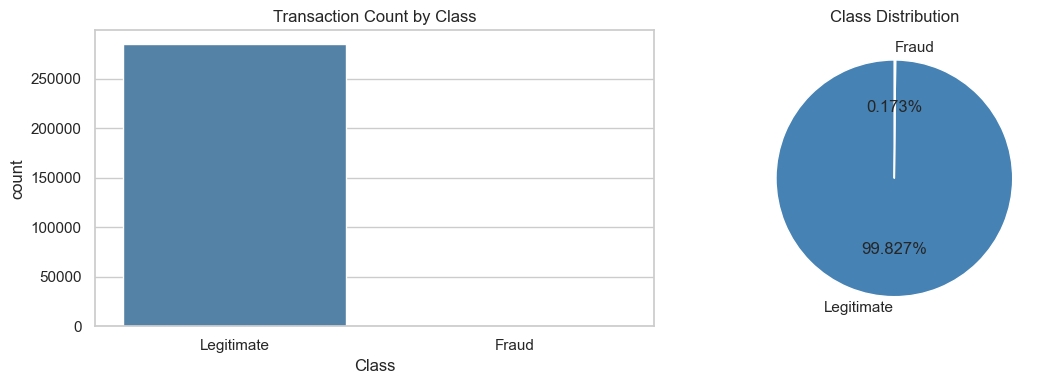

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Class', data=df, ax=axes[0], palette=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Pie chart shows the imbalance more intuitively
axes[1].pie(
    class_counts,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.3f%%',
    colors=['steelblue', 'crimson'],
    startangle=90
)
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.show()

## 3. Amount and Time Distributions

`Amount` and `Time` are the only raw (non-PCA) features. We check if fraud transactions show different patterns.

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


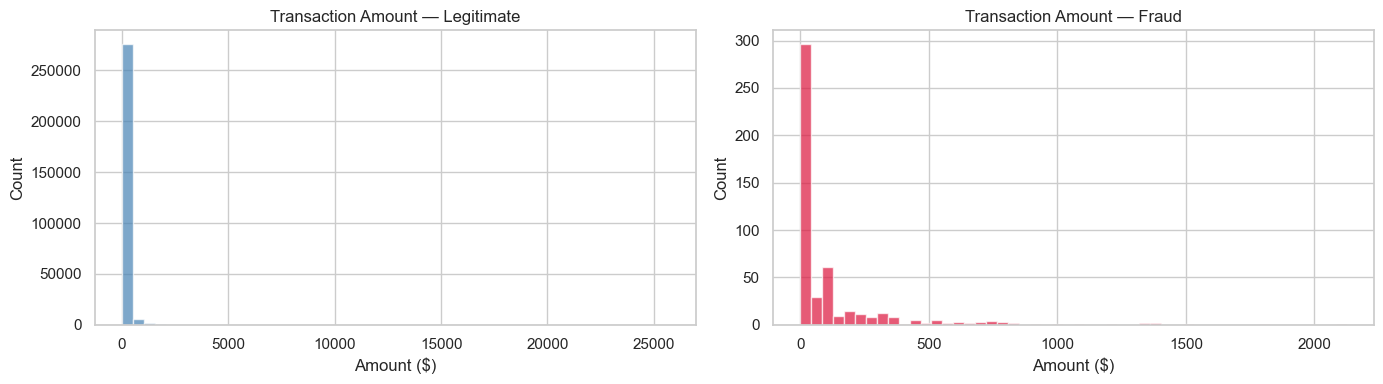

Legitimate — mean: $88.29, max: $25691.16
Fraud      — mean: $122.21, max: $2125.87


In [10]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, color in zip(axes, ['Legitimate', 'Fraud'], ['steelblue', 'crimson']):
    class_val = 0 if label == 'Legitimate' else 1
    subset = df[df['Class'] == class_val]['Amount']
    ax.hist(subset, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'Transaction Amount — {label}')
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Legitimate — mean: ${df[df['Class']==0]['Amount'].mean():.2f}, max: ${df[df['Class']==0]['Amount'].max():.2f}")
print(f"Fraud      — mean: ${df[df['Class']==1]['Amount'].mean():.2f}, max: ${df[df['Class']==1]['Amount'].max():.2f}")

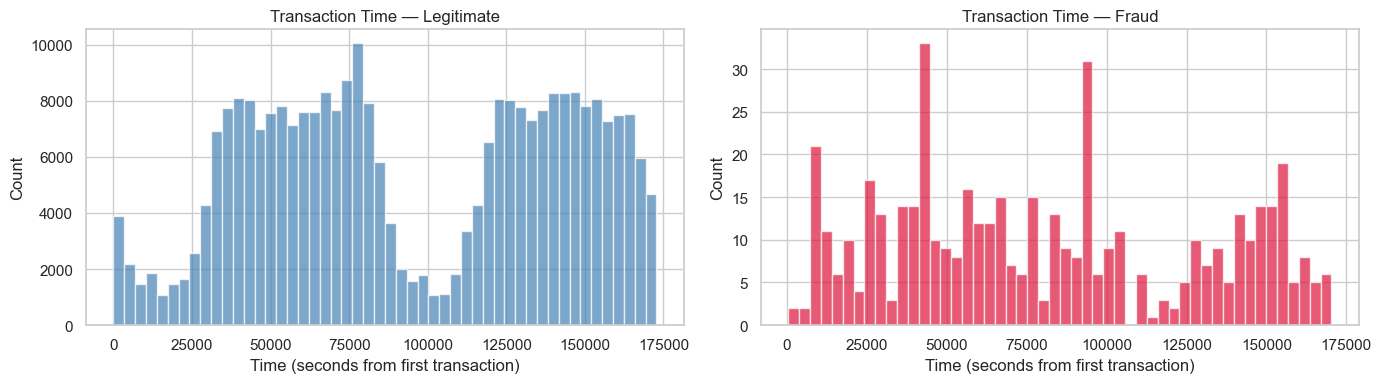

In [11]:
# Time distribution — are fraud transactions clustered at certain times?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, color in zip(axes, ['Legitimate', 'Fraud'], ['steelblue', 'crimson']):
    class_val = 0 if label == 'Legitimate' else 1
    subset = df[df['Class'] == class_val]['Time']
    ax.hist(subset, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'Transaction Time — {label}')
    ax.set_xlabel('Time (seconds from first transaction)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. PCA Feature Distributions (V1–V28)

We can't interpret what these features represent, but features where the fraud and legitimate distributions diverge significantly will be the most predictive.

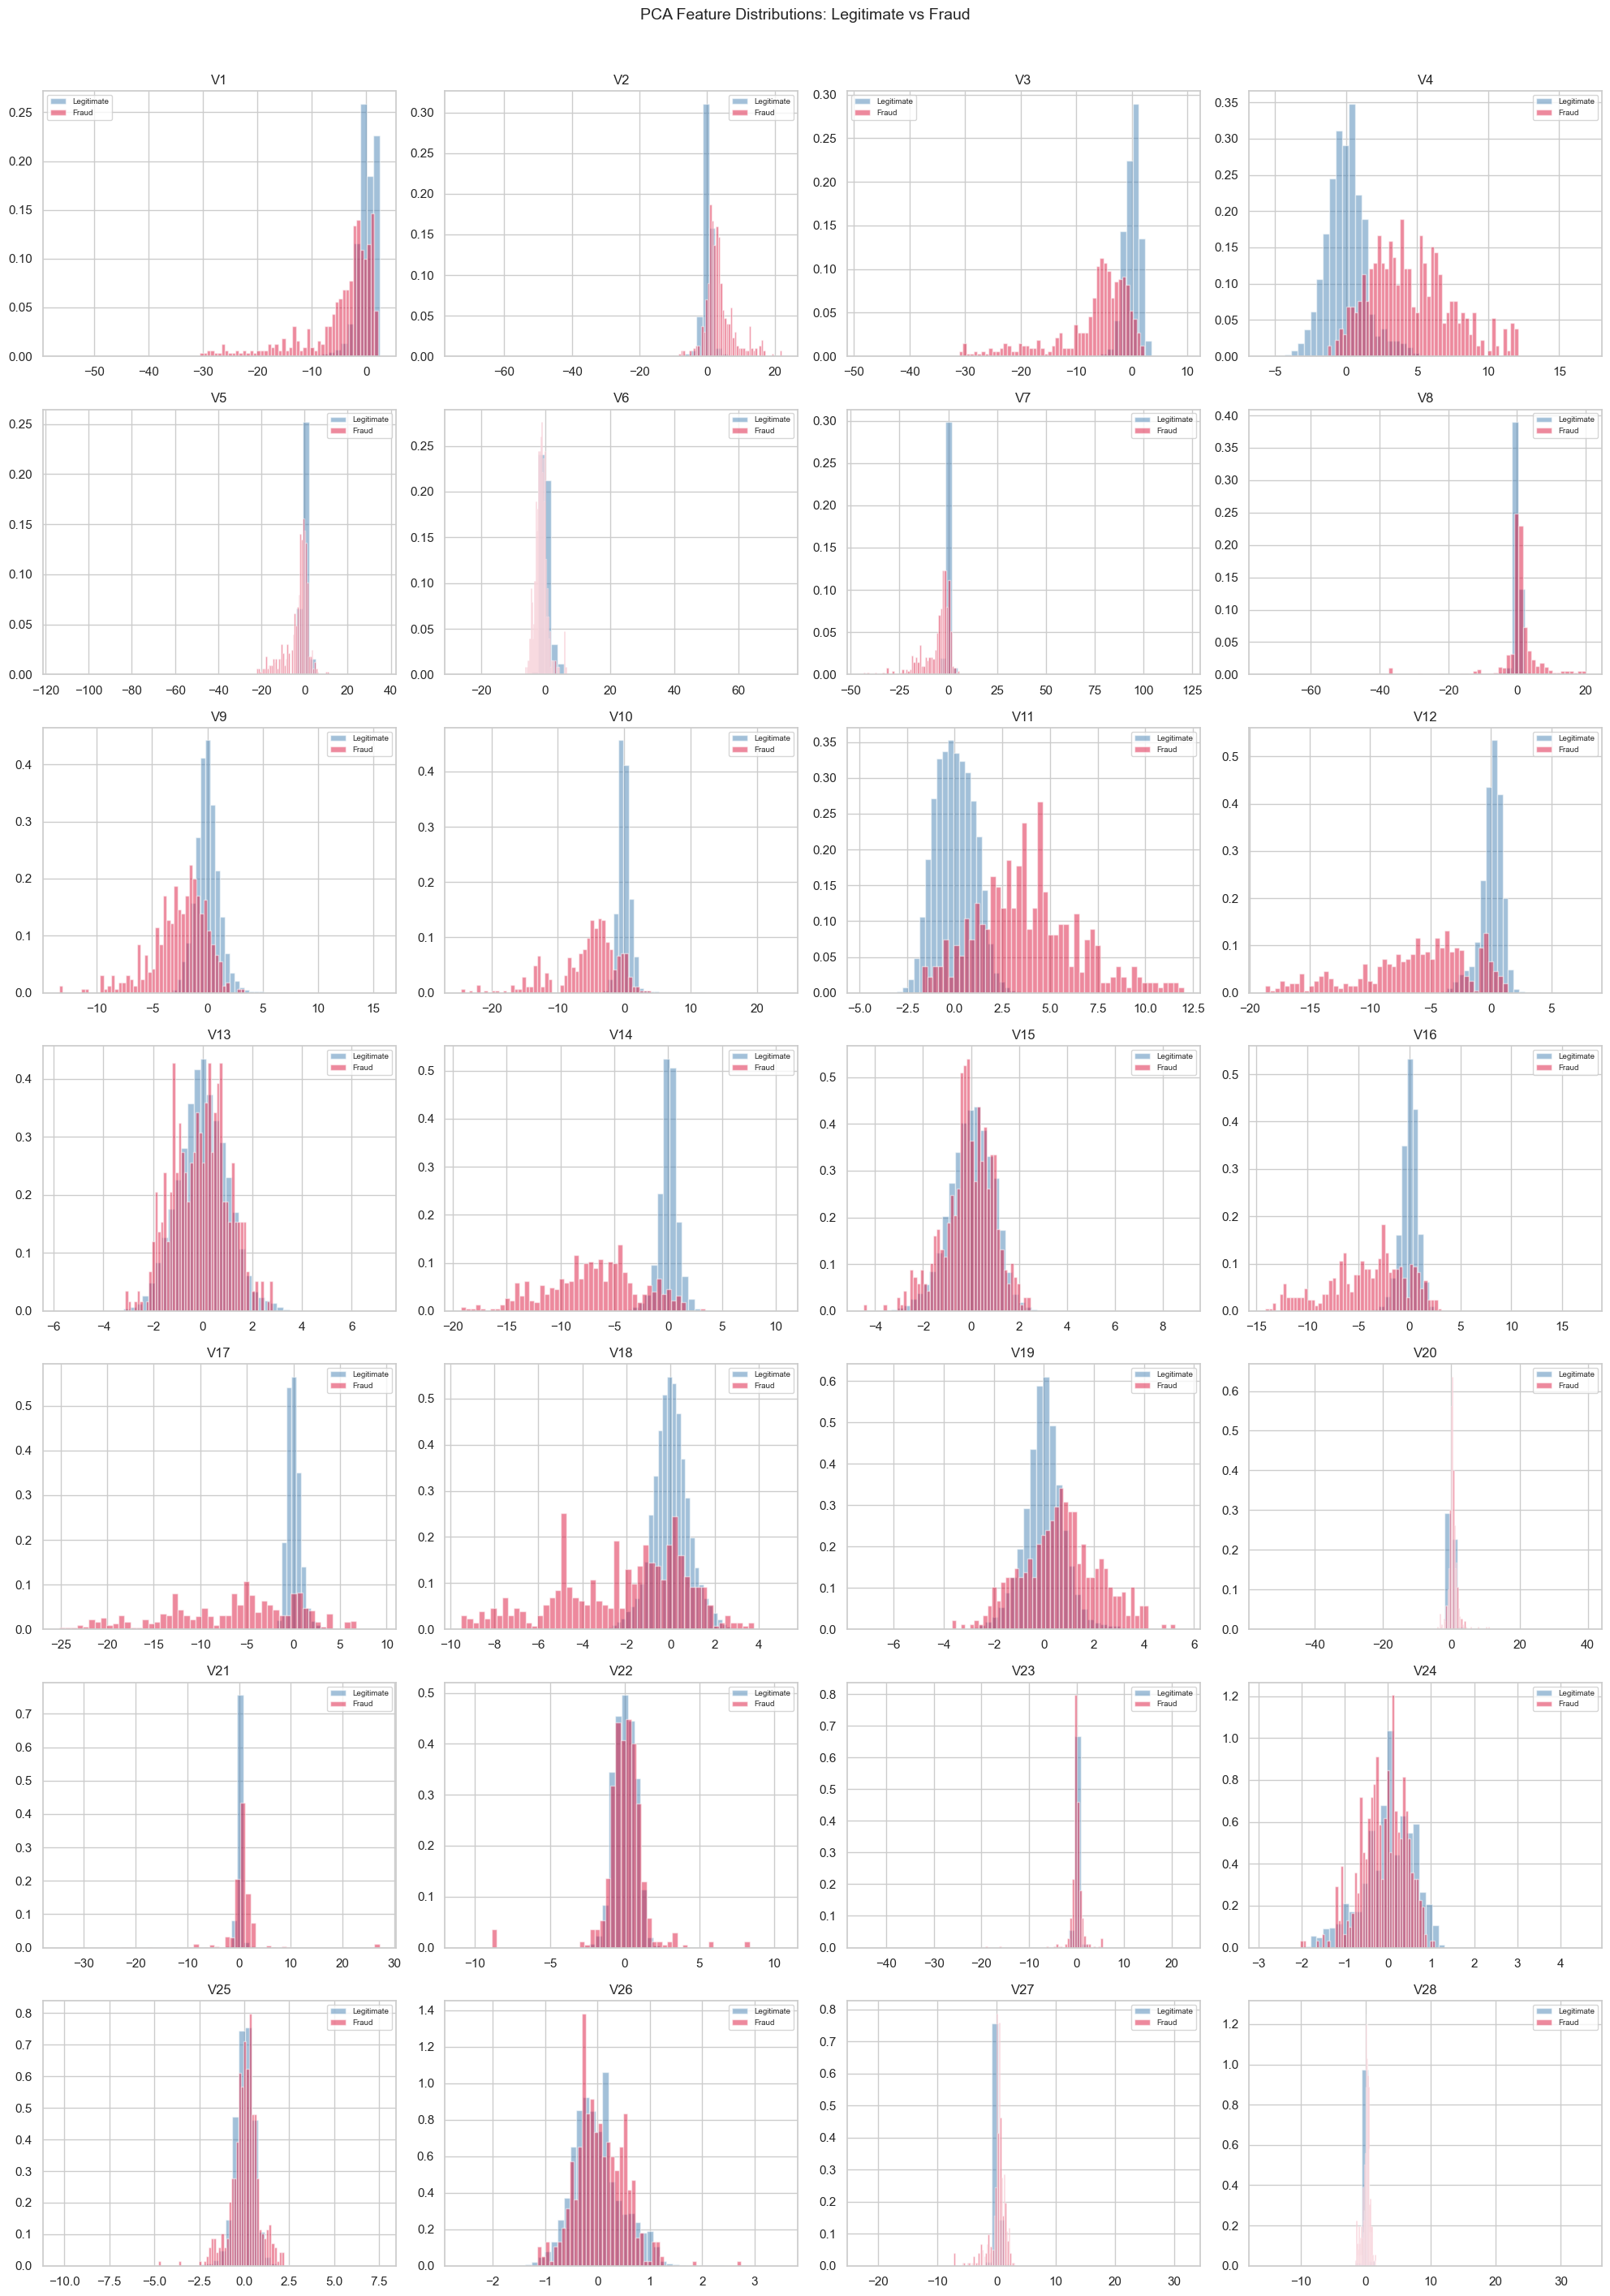

In [12]:
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feature in enumerate(v_features):
    legitimate = df[df['Class'] == 0][feature]
    fraud = df[df['Class'] == 1][feature]
    axes[i].hist(legitimate, bins=50, alpha=0.5, color='steelblue', label='Legitimate', density=True)
    axes[i].hist(fraud, bins=50, alpha=0.5, color='crimson', label='Fraud', density=True)
    axes[i].set_title(feature)
    axes[i].legend(fontsize=7)

plt.suptitle('PCA Feature Distributions: Legitimate vs Fraud', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation with Fraud Label

Which features have the strongest linear correlation with `Class`? High absolute correlation = more predictive signal.

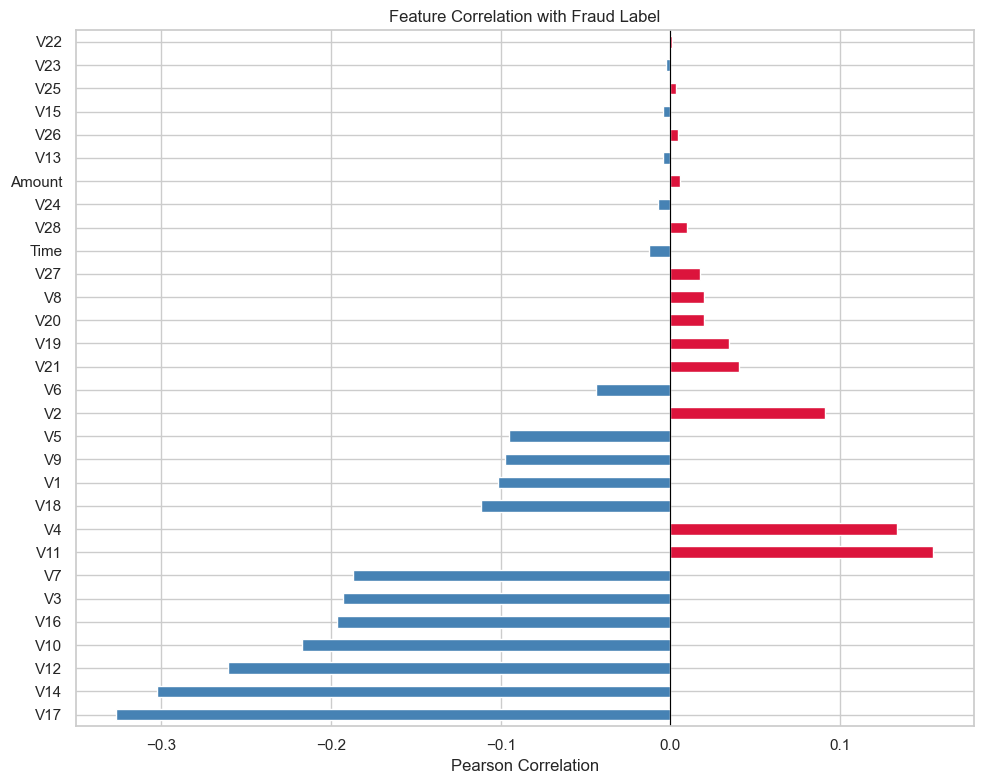

Top 10 most correlated features with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [13]:
correlations = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['crimson' if x > 0 else 'steelblue' for x in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Fraud Label')
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 10 most correlated features with fraud:')
print(correlations.head(10))

## 6. Key Takeaways

Fill this in after running the notebook:

- **Class imbalance:** __% fraud — SMOTE resampling required
- **Missing values:** none
- **Amount:** fraud transactions tend to be ___ (smaller/larger/similar)
- **Time:** fraud ___ (clustered / evenly distributed)
- **Most predictive features:** V___, V___, V___ (based on correlation plot)
- **Feature engineering needed:** scale `Amount`, consider dropping or binning `Time`